# LOINC Crosswalk Retrieval — Ablation Results

Covers primary ablation, secondary ablation, filter ablation, and sentence transformer comparison.  
All evaluation is on the **validation set**. Primary metric: **specimen-aware grouped MRR** (`mrr_grouped`).

---
## 1. Imports and data loading

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.chdir('C:/Users/prach/Desktop/LOINC codes crosswalk project')
sys.path.insert(0, '.')

from src.ablation import load_data, summarize_primary, summarize_by_coverage

sns.set_theme(style='whitegrid', font_scale=1.05)
pd.set_option('display.float_format', '{:.4f}'.format)

COVERAGE_ORDER = [
    'A+M+S+I', 'A+M+S', 'A+M+I', 'A+M',
    'A+S+I',   'A+S',   'A+I',   'A',
    'M+S+I',   'M+S',   'M+I',   'M',
    'S+I',     'S',     'I',     'NONE',
]
NOISE_ORDER = ['low', 'medium', 'high']

MODEL_LABELS = {
    'sentence-transformers/all-MiniLM-L6-v2':                   'MiniLM-L6',
    'cambridgeltl/SapBERT-from-PubMedBERT-fulltext':            'SapBERT',
    'sentence-transformers/msmarco-distilbert-base-v4':          'msmarco-distilbert',
    'pritamdeka/S-PubMedBert-MS-MARCO':                          'S-PubMedBert',
    'neuml/pubmedbert-base-embeddings':                          'PubMedBERT-embed',
    'cambridgeltl/SapBERT-from-PubMedBERT-fulltext-mean-token': 'SapBERT-mean',
}

DATA_DIR = Path('data/results')
df_primary   = pd.read_csv(DATA_DIR / 'primary_ablation.csv')
df_secondary = pd.read_csv(DATA_DIR / 'secondary_ablation.csv')
df_filter    = pd.read_csv(DATA_DIR / 'filter_ablation.csv')
df_st        = pd.read_csv(DATA_DIR / 'sentence_transformer_ablation_results.csv')

df_st['model_label'] = df_st['model_type'].map(MODEL_LABELS)

print('primary   :', df_primary.shape)
print('secondary :', df_secondary.shape)
print('filter    :', df_filter.shape)
print('ST        :', df_st.shape)

primary   : (253440, 36)
secondary : (844800, 35)
filter    : (15840, 36)
ST        : (63360, 26)


---
## 2. Primary ablation

Q1: Which corpus strategy performs best?  
Q2: Does n_distractors matter?  
Q3: Does word, char or mixed (0.5 weight to each) TF-IDF perform best?

In [2]:
print(summarize_primary(df_primary).to_string())

n_distractors                                       0      143
corpus_strategy                model_desc                     
lcn_method_dict_combined       tfidf_word_(1, 1) 0.7474 0.7135
                               tfidf_word_(1, 2) 0.7401 0.7075
component_weighted_method_dict tfidf_mixed_None  0.6748 0.6775
lcn_method_dict_filtered_rn    tfidf_word_(1, 1) 0.6746 0.6886
lcn_filtered_rn_combined       tfidf_word_(1, 1) 0.6730 0.6873
lcn_method_dict_filtered_rn    tfidf_mixed_None  0.6698 0.7134
combined                       tfidf_mixed_None  0.6617 0.6883
lcn_filtered_rn_combined       tfidf_mixed_None  0.6552 0.7119
combined                       tfidf_word_(1, 1) 0.6552 0.6499
component_weighted_method_dict tfidf_word_(1, 2) 0.6548 0.6641
                               tfidf_char_(3, 5) 0.6401 0.7435
lcn_method_dict_filtered_rn    tfidf_word_(1, 2) 0.6367 0.5394
component_weighted_method_dict tfidf_word_(1, 1) 0.6348 0.6404
lcn_filtered_rn_combined       tfidf_word_(1, 2) 0.6312

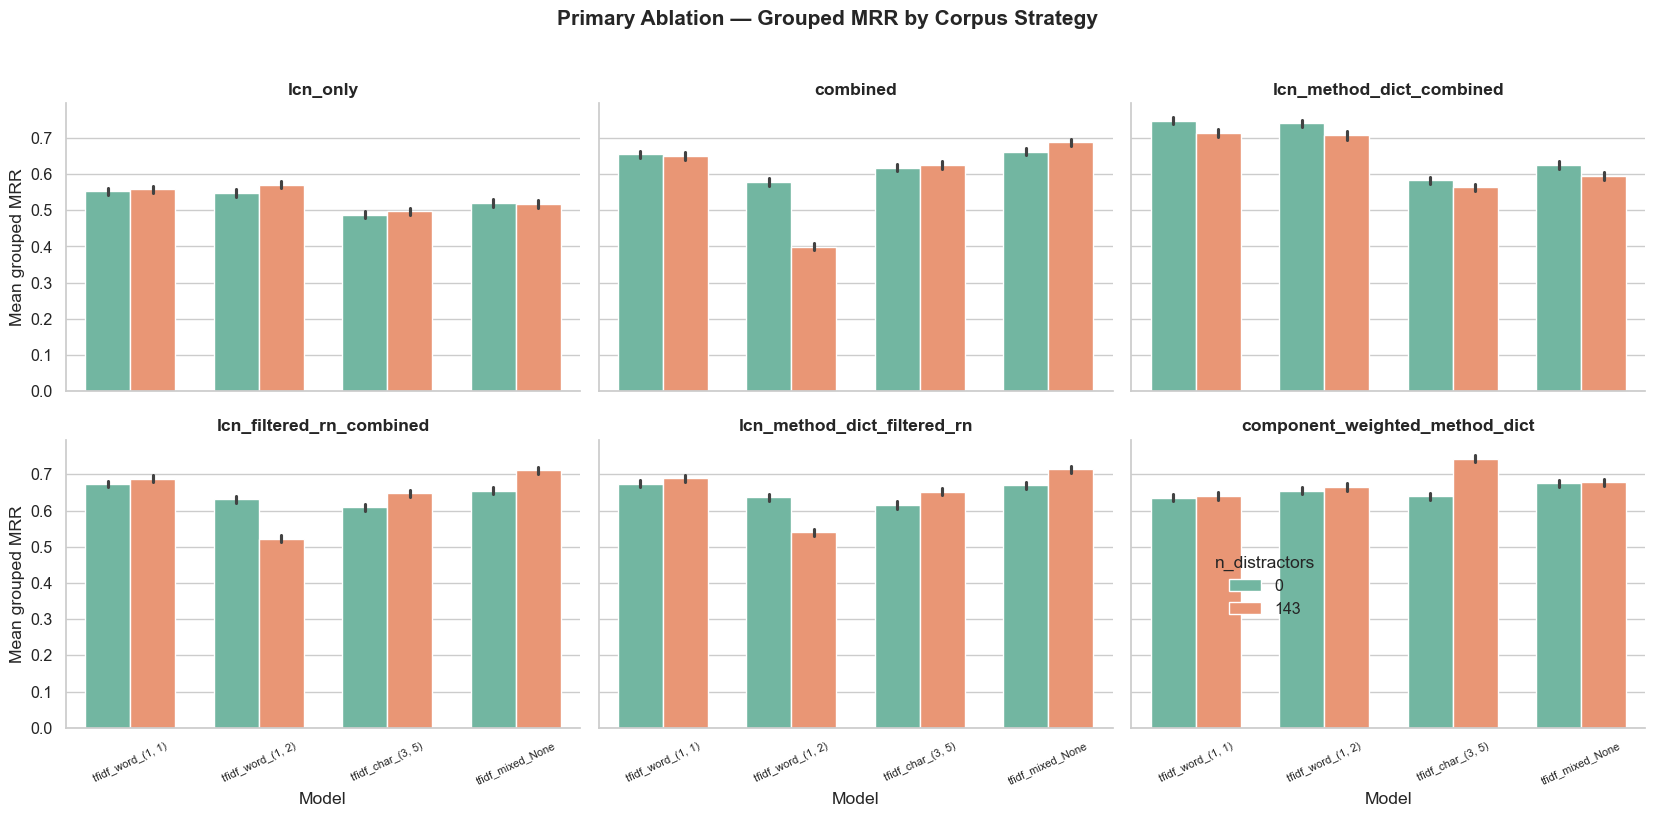

In [3]:
# FacetGrid: one panel per corpus strategy, bars grouped by model, hue = n_distractors
g = sns.FacetGrid(df_primary, col='corpus_strategy', col_wrap=3, height=4, aspect=1.3, sharey=True)
g.map_dataframe(sns.barplot, x='model_desc', y='mrr_grouped', hue='n_distractors', palette='Set2', width=0.7)
g.add_legend(title='n_distractors', bbox_to_anchor=(0.8, 0.3))
g.set_titles('{col_name}', fontsize=11, fontweight='bold')
g.set_axis_labels('Model', 'Mean grouped MRR')
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=25, labelsize=8)
g.figure.suptitle('Primary Ablation — Grouped MRR by Corpus Strategy', y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_DIR / 'primary_ablation.png', dpi=130, bbox_inches='tight')
plt.show()

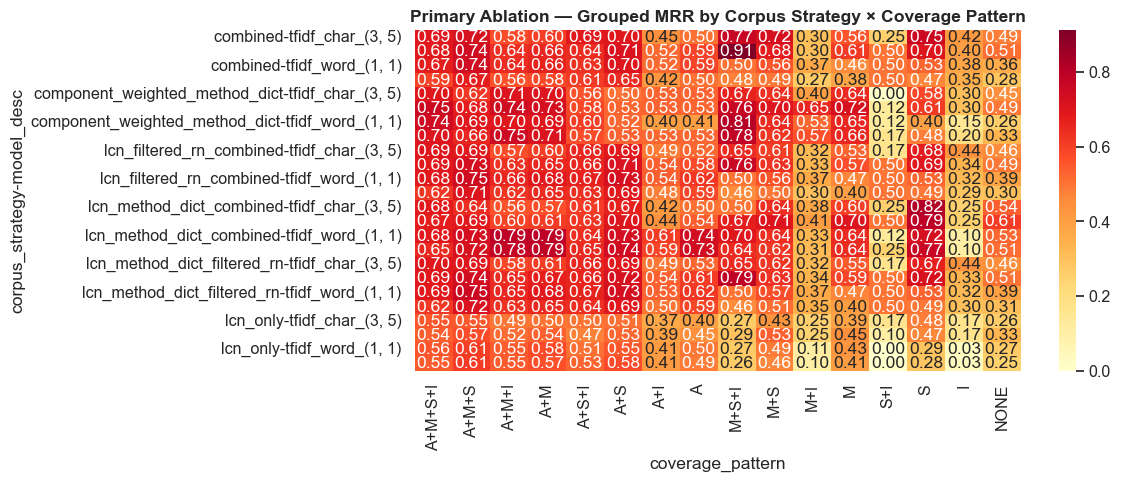

In [4]:
# Heatmap: grouped MRR by corpus strategy × coverage pattern
coverage_tbl = summarize_by_coverage(df_primary)
present = [p for p in COVERAGE_ORDER if p in coverage_tbl.columns]
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(coverage_tbl[present], annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
ax.set_title('Primary Ablation — Grouped MRR by Corpus Strategy × Coverage Pattern', fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_DIR / 'primary_ablation_coverage_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 3. Secondary ablation

Finer sweep: corpus strategy × model type (word/char/mixed) × alpha × n_distractors.  
Here alpha refers to the weight given to the word model vectors while char is weighted as 1-alpha.

In [5]:
# ── Reconstruct model_desc and model_cat ─────────────────────────────────────
def make_model_desc(row):
    if row['model_type'] == 'tfidf_mixed':
        return f"mixed_w{row['ngram_word']}_c{row['ngram_char']}_a{row['alpha']}"
    elif row['model_type'] == 'tfidf_word':
        return f"tfidf_word_{row['ngram_word']}"
    return f"tfidf_char_{row['ngram_char']}"

def make_model_cat(row):
    if row['model_type'] == 'tfidf_word': return f"word {row['ngram_word']}"
    if row['model_type'] == 'tfidf_char': return f"char {row['ngram_char']}"
    return 'mixed'

df_secondary['model_desc'] = df_secondary.apply(make_model_desc, axis=1)
df_secondary['model_cat']  = df_secondary.apply(make_model_cat, axis=1)

# Config-level aggregate
agg = (
    df_secondary
    .groupby(['corpus_strategy', 'model_type', 'model_desc', 'model_cat',
              'n_distractors', 'ngram_word', 'ngram_char', 'alpha'], dropna=False)
    ['mrr_grouped'].mean()
    .reset_index()
)

corpus_labels = {
    'lcn_method_dict_combined':       'lcn+method\ndict',
    'lcn_method_dict_filtered_rn':    'lcn+method\ndict+rn',
    'component_weighted_method_dict': 'comp\nweighted',
    'lcn_filtered_rn_combined':       'lcn+rn\nfiltered',
}
bar_order = ['comp\nweighted', 'lcn+method\ndict', 'lcn+method\ndict+rn', 'lcn+rn\nfiltered']
agg['corpus_label'] = agg['corpus_strategy'].map(corpus_labels)

best_n = agg.groupby('n_distractors')['mrr_grouped'].mean().idxmax()
print(f'Best n_distractors overall: {best_n}')

Best n_distractors overall: 100


In [6]:
# Best config per corpus strategy summary
best_by_corpus = (
    agg.sort_values('mrr_grouped', ascending=False)
    .groupby('corpus_strategy', as_index=False).first()
)
print('Best config per corpus strategy (overall):')
print(best_by_corpus[['corpus_strategy', 'model_cat', 'ngram_word', 'ngram_char', 'alpha', 'n_distractors', 'mrr_grouped']].round(4).to_string(index=False))

Best config per corpus strategy (overall):
               corpus_strategy model_cat ngram_word ngram_char  alpha  n_distractors  mrr_grouped
component_weighted_method_dict     mixed     (1, 2)     (3, 6) 0.3000            143       0.7598
      lcn_filtered_rn_combined     mixed     (1, 1)     (3, 5) 0.7000            143       0.7115
      lcn_method_dict_combined     mixed     (1, 2)     (3, 6) 0.7000              0       0.7475
   lcn_method_dict_filtered_rn     mixed     (1, 1)     (3, 5) 0.7000            143       0.7133


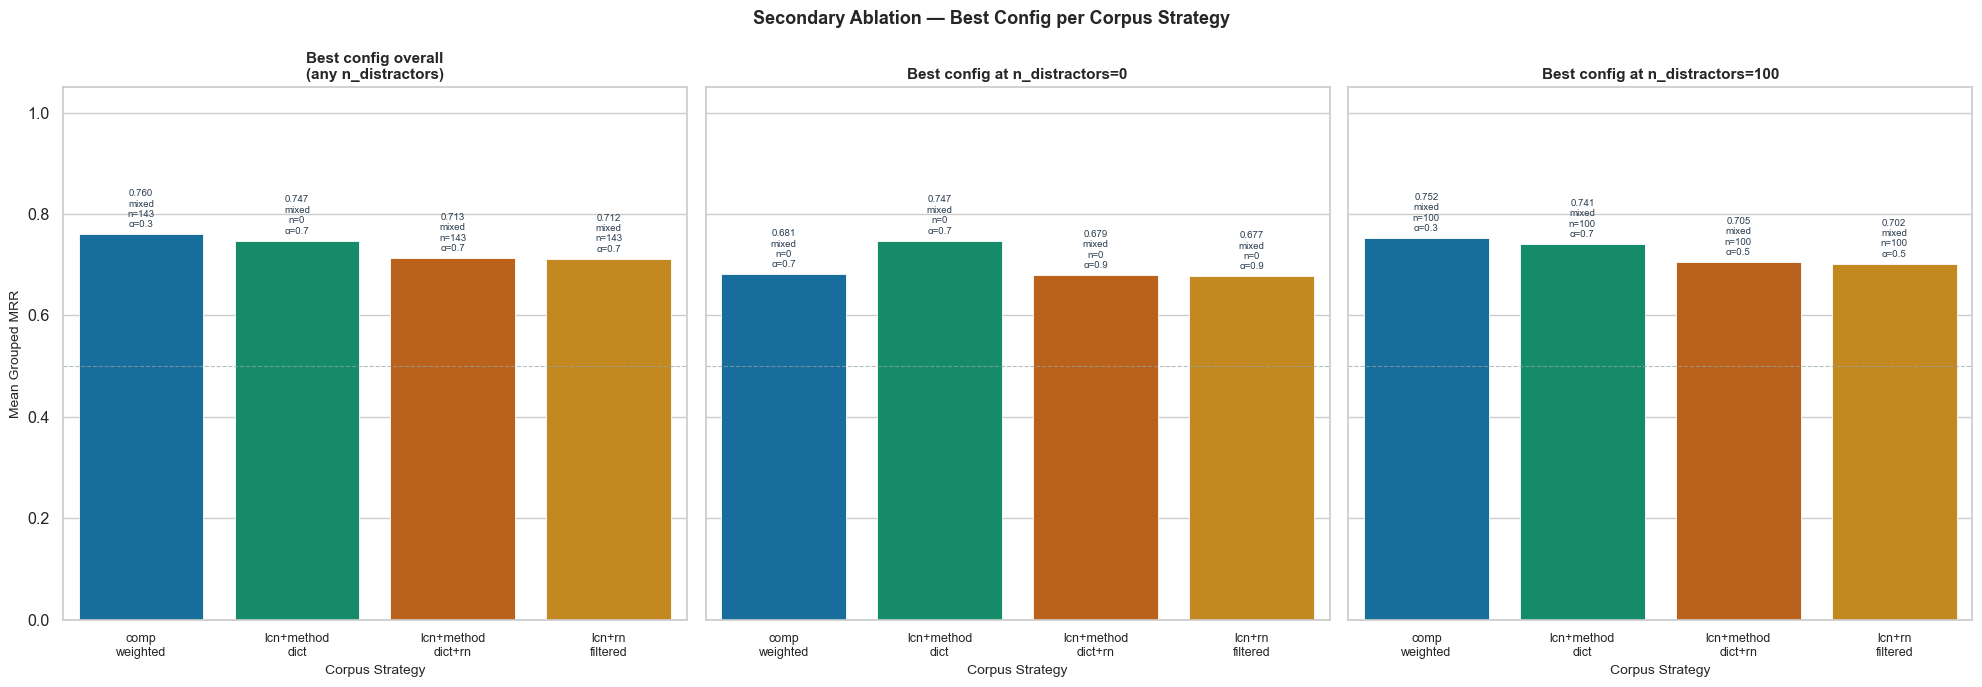

In [7]:
# Three-panel bar: best config per corpus strategy at (overall / n=0 / best_n)
def prep_panel(data):
    return (
        data.sort_values('mrr_grouped', ascending=False)
        .groupby('corpus_strategy', as_index=False).first()
        .assign(corpus_label=lambda d: d['corpus_strategy'].map(corpus_labels))
    )

p1 = prep_panel(agg)
p2 = prep_panel(agg[agg['n_distractors'] == 0])
p3 = prep_panel(agg[agg['n_distractors'] == best_n])

fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)
for ax, (data, title) in zip(axes, [
    (p1, 'Best config overall\n(any n_distractors)'),
    (p2, 'Best config at n_distractors=0'),
    (p3, f'Best config at n_distractors={best_n}'),
]):
    sns.barplot(data=data, x='corpus_label', y='mrr_grouped', hue='corpus_label',
                order=bar_order, palette='colorblind', ax=ax,
                errorbar=None, edgecolor='white', linewidth=0.6, legend=False)
    data_idx = data.set_index('corpus_label')
    for i, label in enumerate(bar_order):
        row = data_idx.loc[label]
        alpha_str = f"\nα={row.alpha}" if row.model_cat == 'mixed' else ''
        ax.text(i, row.mrr_grouped + 0.01,
                f"{row.mrr_grouped:.3f}\n{row.model_cat}\nn={int(row.n_distractors)}{alpha_str}",
                ha='center', va='bottom', fontsize=7, color='#2c3e50')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Corpus Strategy', fontsize=10)
    ax.set_ylabel('Mean Grouped MRR' if ax is axes[0] else '', fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color='#95a5a6', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.tick_params(axis='x', labelsize=9)

fig.suptitle('Secondary Ablation — Best Config per Corpus Strategy', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig(DATA_DIR / 'secondary_ablation_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# n_distractors sensitivity: two focus strategies × word(1,1) vs best mixed
FOCUS_STRATEGIES = ['lcn_method_dict_combined', 'component_weighted_method_dict']
focus_labels = {
    'lcn_method_dict_combined':       'lcn+method dict',
    'component_weighted_method_dict': 'comp weighted',
}

# Coverage pattern breakdown: best config per focus strategy
best_configs = (
    agg[agg['corpus_strategy'].isin(FOCUS_STRATEGIES)]
    .sort_values('mrr_grouped', ascending=False)
    .groupby('corpus_strategy', as_index=False).first()
    [['corpus_strategy', 'model_type', 'ngram_word', 'ngram_char', 'alpha', 'n_distractors', 'model_cat']]
)
print(best_configs[['corpus_strategy', 'model_cat', 'ngram_word','ngram_char', 'n_distractors', 'alpha']].to_string(index=False),'\n')

               corpus_strategy model_cat ngram_word ngram_char  n_distractors  alpha
component_weighted_method_dict     mixed     (1, 2)     (3, 6)            143 0.3000
      lcn_method_dict_combined     mixed     (1, 2)     (3, 6)              0 0.7000 



Although the best performance for the lcn_method_dict_combined strategy is with a mixed model, the difference between this model and the simpler word unigram model is negligible. 

In [9]:
agg[agg['corpus_strategy']=="lcn_method_dict_combined"].sort_values('mrr_grouped', ascending=False).head(5)[['corpus_strategy', 'model_type', 'ngram_word', 'ngram_char', 'alpha', 'n_distractors', 'model_cat','mrr_grouped']]

,corpus_strategy,model_type,ngram_word,ngram_char,alpha,n_distractors,model_cat,mrr_grouped
108,lcn_method_dict_combined,tfidf_mixed,"(1, 2)","(3, 6)",0.7000,0,mixed,0.7475
116,lcn_method_dict_combined,tfidf_word,"(1, 1)","(3, 5)",0.5000,0,"word (1, 1)",0.7474
112,lcn_method_dict_combined,tfidf_mixed,"(1, 2)","(3, 6)",0.9000,0,mixed,0.7458
109,lcn_method_dict_combined,tfidf_mixed,"(1, 2)","(3, 6)",0.7000,50,mixed,0.7445
113,lcn_method_dict_combined,tfidf_mixed,"(1, 2)","(3, 6)",0.9000,50,mixed,0.7432


Note the differences in the mrr_grouped metric as the n_distractors are increased for the best config for each of the two top strategies: `lcn_method_dict_combined` and `component_weighted_method_dict`. The former's performance monotonically degrades with the number of distractors.

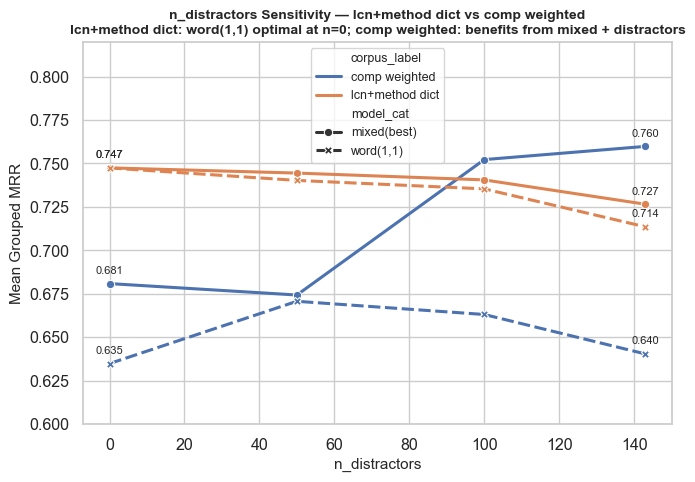

In [10]:
# n_distractors sensitivity: two focus strategies × word(1,1) vs best mixed
FOCUS_STRATEGIES = ['lcn_method_dict_combined', 'component_weighted_method_dict']
focus_labels = {
    'lcn_method_dict_combined':       'lcn+method dict',
    'component_weighted_method_dict': 'comp weighted',
}

focus = agg[agg['corpus_strategy'].isin(FOCUS_STRATEGIES)].copy()
focus['model_cat'] = focus['model_type'].map(
    {'tfidf_word': 'word(1,1)', 'tfidf_char': None, 'tfidf_mixed': 'mixed(best)'}
)
focus = focus[focus['model_cat'].notna()]
focus = focus[(focus['model_type'] != 'tfidf_word') | (focus['ngram_word'].astype(str) == '(1, 1)')]
focus = (
    focus.sort_values('mrr_grouped', ascending=False)
    .groupby(['corpus_strategy', 'model_cat', 'n_distractors'], as_index=False).first()
    .sort_values('n_distractors')
)
focus['corpus_label'] = focus['corpus_strategy'].map(focus_labels)

fig, ax = plt.subplots(figsize=(7, 5))
sns.lineplot(data=focus, x='n_distractors', y='mrr_grouped',
             hue='corpus_label', style='model_cat',
             markers=True, dashes=True, linewidth=2.2, ax=ax)
for (cs, model_cat), grp in focus.groupby(['corpus_label', 'model_cat']):
    for _, pt in grp.sort_values('n_distractors').iloc[[0, -1]].iterrows():
        ax.annotate(f"{pt['mrr_grouped']:.3f}",
                    xy=(pt['n_distractors'], pt['mrr_grouped']),
                    xytext=(0, 7), textcoords='offset points', ha='center', fontsize=8)
ax.set_xlabel('n_distractors', fontsize=11)
ax.set_ylabel('Mean Grouped MRR', fontsize=11)
ax.set_ylim(0.60, 0.82)
ax.set_title(
    'n_distractors Sensitivity — lcn+method dict vs comp weighted\n'
    'lcn+method dict: word(1,1) optimal at n=0; comp weighted: benefits from mixed + distractors',
    fontsize=10, fontweight='bold')
ax.legend(title='', fontsize=9)
fig.tight_layout()
plt.savefig(DATA_DIR / 'secondary_distractor_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

               corpus_strategy   model_cat  n_distractors  alpha
component_weighted_method_dict       mixed            143 0.3000
      lcn_method_dict_combined word (1, 1)              0 0.5000


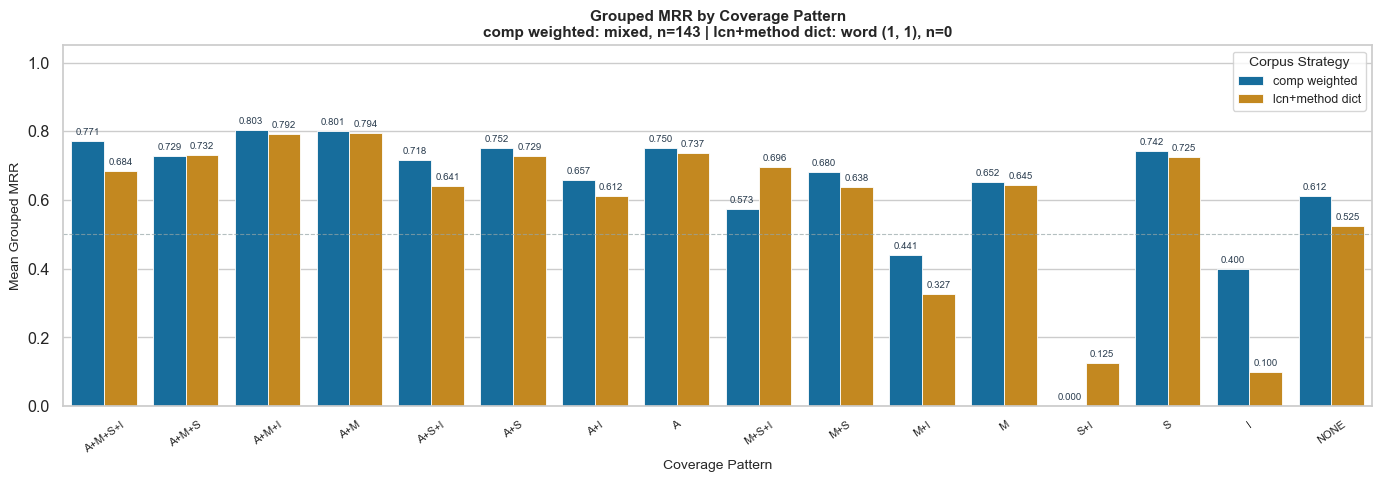

In [11]:
# Override: fix lcn_method_dict_combined to word(1,1), n=0
# (tied with best mixed at 0.7474 vs 0.7475 — simpler model preferred)
lcn_word11 = agg[
    (agg["corpus_strategy"] == "lcn_method_dict_combined") &
    (agg["model_type"] == "tfidf_word") &
    (agg["ngram_word"].astype(str) == "(1, 1)") &
    (agg["n_distractors"] == 0)
].iloc[0]

best_configs.loc[
    best_configs["corpus_strategy"] == "lcn_method_dict_combined",
    ["model_type", "ngram_word", "ngram_char", "alpha", "n_distractors", "model_cat"]
] = [lcn_word11["model_type"], lcn_word11["ngram_word"], lcn_word11["ngram_char"],
     lcn_word11["alpha"], lcn_word11["n_distractors"], lcn_word11["model_cat"]]

print(best_configs[["corpus_strategy", "model_cat", "n_distractors", "alpha"]].to_string(index=False))
merge_keys = ['corpus_strategy', 'model_type', 'ngram_word', 'ngram_char', 'alpha', 'n_distractors']
cov_agg = (
    df_secondary
    .merge(best_configs[merge_keys], on=merge_keys, how='inner')
    .groupby(['corpus_strategy', 'coverage_pattern'])['mrr_grouped'].mean()
    .reset_index()
)
cov_agg['corpus_label'] = cov_agg['corpus_strategy'].map(focus_labels)
shared = (cov_agg.groupby('coverage_pattern')['corpus_strategy'].nunique()
          .pipe(lambda s: s[s == 2].index))
present_order = [p for p in COVERAGE_ORDER if p in shared]
cov_agg = cov_agg[cov_agg['coverage_pattern'].isin(present_order)]

config_strs = []
for _, cfg in best_configs.iterrows():
    alpha_str = f", α={cfg.alpha}" if cfg.model_cat == 'mixed(best)' else ''
    config_strs.append(f"{focus_labels[cfg.corpus_strategy]}: {cfg.model_cat}, n={int(cfg.n_distractors)}{alpha_str}")

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=cov_agg, x='coverage_pattern', y='mrr_grouped', hue='corpus_label',
            order=present_order, palette='colorblind', ax=ax, errorbar=None,
            edgecolor='white', linewidth=0.6)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=3, color='#2c3e50')
ax.set_title('Grouped MRR by Coverage Pattern\n' + ' | '.join(config_strs), fontsize=11, fontweight='bold')
ax.set_xlabel('Coverage Pattern', fontsize=10)
ax.set_ylabel('Mean Grouped MRR', fontsize=10)
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=35, labelsize=8)
ax.axhline(0.5, color='#95a5a6', linestyle='--', linewidth=0.8, alpha=0.7)
ax.legend(title='Corpus Strategy', fontsize=9, title_fontsize=10)
fig.tight_layout()
plt.savefig(DATA_DIR / 'secondary_coverage_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Given the more parsiminous config with word unigram model with 0 distractors, and a relatively close performance to the best config (`comp_weighted_method_dict`), the filter ablation will focus on the `lcn_method_dict_combined` strategy. 

---
## 4. Filter ablation

Three conditions on best TF-IDF config (`lcn_method_dict_combined`, word(1,1), 100 distractors):

| Condition | Description |
|---|---|
| `no_filter` | Baseline — no post-retrieval reranking |
| `oracle_filter` | Ground-truth method+specimen demotion — upper bound |
| `brand_filter` | Brand-token method imputation — production-feasible |

In [12]:
CONDITION_ORDER = ['no_filter', 'oracle_filter', 'brand_filter']

# Headline summary
print('Filter ablation — overall grouped MRR')
print(
    df_filter.groupby('filter_condition')['mrr_grouped']
    .mean().reindex(CONDITION_ORDER).round(4).to_string()
)

Filter ablation — overall grouped MRR
filter_condition
no_filter       0.7474
oracle_filter   0.7666
brand_filter    0.7476


15:35:42 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
15:35:42 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
15:35:42 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
15:35:42 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


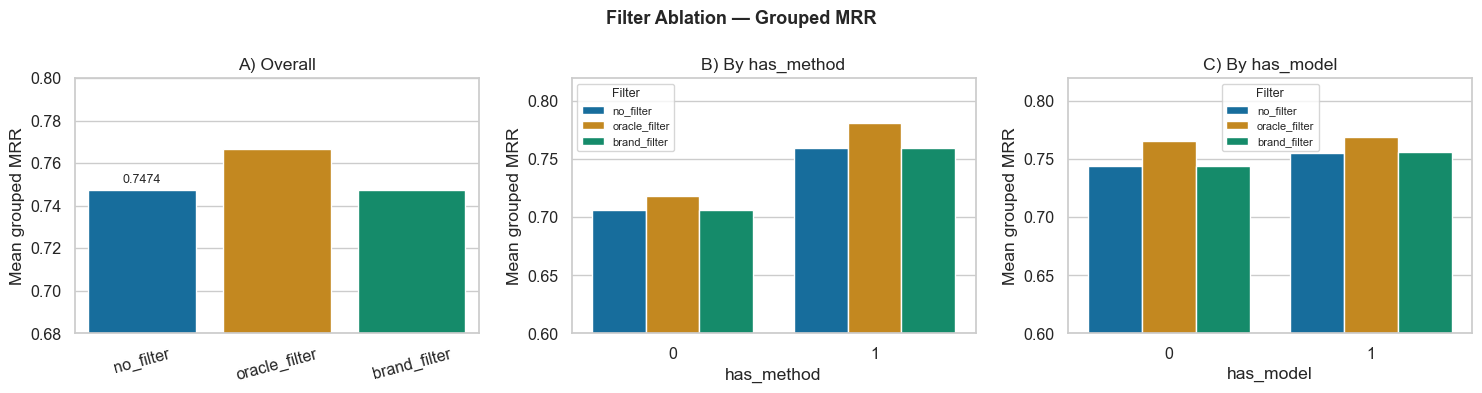

In [13]:
# Three-panel: overall / by has_method / by has_model
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle('Filter Ablation — Grouped MRR', fontsize=13, fontweight='bold')

# Panel A: overall
overall = df_filter.groupby('filter_condition')['mrr_grouped'].mean().reindex(CONDITION_ORDER).reset_index()
sns.barplot(data=overall, x='filter_condition', y='mrr_grouped', hue='filter_condition',
            order=CONDITION_ORDER, palette='colorblind', ax=axes[0],
            errorbar=None, edgecolor='white', legend=False)
axes[0].bar_label(axes[0].containers[0], fmt='%.4f', fontsize=9, padding=3)
axes[0].set_ylim(0.68, 0.80)
axes[0].set_title('A) Overall')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)

# Panels B and C: by has_method / has_model
for ax, col, label in zip(axes[1:], ['has_method', 'has_model'], ['B) By has_method', 'C) By has_model']):
    data = (
        df_filter.groupby([col, 'filter_condition'])['mrr_grouped'].mean()
        .reset_index()
    )
    sns.barplot(data=data, x=col, y='mrr_grouped', hue='filter_condition',
                hue_order=CONDITION_ORDER, palette='colorblind', ax=ax,
                errorbar=None, edgecolor='white')
    ax.set_ylim(0.60, 0.82)
    ax.set_title(label)
    ax.set_xlabel(col)
    ax.legend(fontsize=8, title='Filter', title_fontsize=9)

for ax in axes:
    ax.set_ylabel('Mean grouped MRR')

plt.tight_layout()
plt.savefig(DATA_DIR / 'filter_ablation_overview.png', bbox_inches='tight')
plt.show()

C:\Users\prach\AppData\Local\Temp\ipykernel_30480\887510675.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(present, rotation=35, ha='right', fontsize=9)


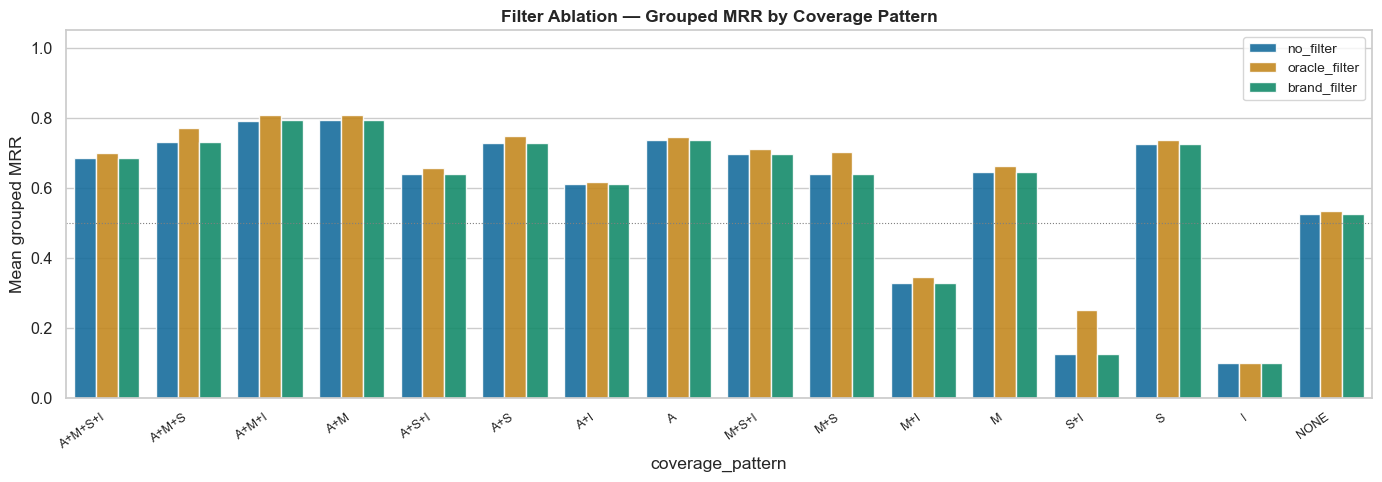

In [14]:
# By coverage pattern
cov_fa = (
    df_filter.groupby(['coverage_pattern', 'filter_condition'])['mrr_grouped'].mean()
    .reset_index()
)
present = [p for p in COVERAGE_ORDER if p in cov_fa['coverage_pattern'].unique()]
cov_fa = cov_fa[cov_fa['coverage_pattern'].isin(present)]
cov_fa['coverage_pattern'] = pd.Categorical(cov_fa['coverage_pattern'], categories=present, ordered=True)

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=cov_fa, x='coverage_pattern', y='mrr_grouped', hue='filter_condition',
            hue_order=CONDITION_ORDER, palette='colorblind', ax=ax,
            errorbar=None, edgecolor='white', alpha=0.9)
ax.set_xticklabels(present, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Mean grouped MRR')
ax.set_title('Filter Ablation — Grouped MRR by Coverage Pattern', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', lw=0.8, linestyle=':')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(DATA_DIR / 'filter_ablation_by_coverage.png', bbox_inches='tight')
plt.show()

In [15]:
# Oracle delta table
cov_pivot = (
    df_filter.groupby(['coverage_pattern', 'filter_condition'])['mrr_grouped'].mean()
    .unstack('filter_condition').reindex(columns=CONDITION_ORDER)
)
present = [p for p in COVERAGE_ORDER if p in cov_pivot.index]
cov_pivot = cov_pivot.reindex(present)

delta_tbl = cov_pivot.assign(
    oracle_delta_pp=((cov_pivot['oracle_filter'] - cov_pivot['no_filter']) * 100).round(2),
    brand_delta_pp= ((cov_pivot['brand_filter']  - cov_pivot['no_filter']) * 100).round(2),
).round(4)
delta_tbl.sort_values('oracle_delta_pp', ascending=False)

filter_condition,no_filter,oracle_filter,brand_filter,oracle_delta_pp,brand_delta_pp
coverage_pattern,,,,,
S+I,0.1250,0.2500,0.1250,12.5000,0.0000
M+S,0.6382,0.7017,0.6382,6.3500,0.0000
A+M+S,0.7322,0.7703,0.7322,3.8100,0.0000
M+I,0.3272,0.3457,0.3272,1.8500,0.0000
A+S,0.7292,0.7475,0.7292,1.8300,0.0000
A+M+I,0.7919,0.8086,0.7942,1.6800,0.2300
M,0.6449,0.6611,0.6449,1.6200,0.0000
A+S+I,0.6407,0.6567,0.6407,1.6000,0.0000
A+M+S+I,0.6844,0.6998,0.6844,1.5300,0.0000


In [16]:
# Error taxonomy (TF-IDF no filter)
df_tfidf_nf = df_filter[df_filter['filter_condition'] == 'no_filter'].copy()

print('TF-IDF (no filter) error taxonomy')
for label, expr in [
    ('top-1 accuracy',               df_tfidf_nf['top1'].mean()),
    ('top-3 accuracy',               df_tfidf_nf['top3'].mean()),
    ('top-5 accuracy',               df_tfidf_nf['top5'].mean()),
    ('specificity mismatch rate',    df_tfidf_nf['specificity_mismatch'].mean()),
    ('true retrieval failures (MRR=0)', (df_tfidf_nf['mrr_grouped'] == 0).mean()),
]:
    print(f'  {label:40s}: {expr:.4f}')

TFIDF_BASELINE = df_tfidf_nf['mrr_grouped'].mean()
print(f'\nTF-IDF baseline (no_filter): {TFIDF_BASELINE:.4f}')

TF-IDF (no filter) error taxonomy
  top-1 accuracy                          : 0.2820
  top-3 accuracy                          : 0.4354
  top-5 accuracy                          : 0.5277
  specificity mismatch rate               : 0.4545
  true retrieval failures (MRR=0)         : 0.1483

TF-IDF baseline (no_filter): 0.7474


In [17]:
# Failure breakdown by coverage pattern
(
    df_tfidf_nf.groupby('coverage_pattern')
    .agg(
        n=('mrr_grouped', 'count'),
        mrr_grouped_mean=('mrr_grouped', 'mean'),
        top1_rate=('top1', 'mean'),
        true_failure_rate=('mrr_grouped', lambda x: (x == 0).mean()),
        spec_mismatch_rate=('specificity_mismatch', 'mean'),
    )
    .round(4)
    .reindex([p for p in COVERAGE_ORDER if p in df_tfidf_nf['coverage_pattern'].unique()])
)

,n,mrr_grouped_mean,top1_rate,true_failure_rate,spec_mismatch_rate
coverage_pattern,,,,,
A+M+S+I,150,0.6844,0.1267,0.1533,0.6467
A+M+S,1178,0.7322,0.2216,0.1333,0.5136
A+M+I,326,0.7919,0.3773,0.0920,0.3804
A+M,2184,0.7943,0.3077,0.1172,0.4611
A+S+I,52,0.6407,0.0769,0.1538,0.6346
A+S,271,0.7292,0.1697,0.1587,0.5609
A+I,107,0.6121,0.2523,0.2336,0.2991
A,648,0.7369,0.3086,0.1944,0.4198
M+S+I,17,0.6961,0.3529,0.1765,0.4706


---
## 5. Sentence transformer comparison

Six models tested across two corpus strategies:
- **regular_corpus** — standard LOINC long_common_name
- **boosted_corpus** — additionally augmented with system and method   

Note: `clean_text` (TF-IDF preprocessing) is **not** applied to ST inputs - instead some lightweight normalization is applied to the ELR queries, including some abbreviation expansion to more common representations. All preprocessing ensures that natural language representations are respected (example long_common_name is not artifically expanded with tokens to avoid degrading the semantic structure.)

In [18]:
# Summary table
print('Sentence transformer grouped MRR (model × strategy)')
(
    df_st.groupby(['model_label', 'strategy'])['mrr_grouped'].mean()
    .unstack('strategy').round(4)
    .sort_values('regular_corpus', ascending=False)
)

Sentence transformer grouped MRR (model × strategy)


strategy,boosted_corpus,regular_corpus
model_label,,
S-PubMedBert,0.4047,0.6170
MiniLM-L6,0.3110,0.5733
PubMedBERT-embed,0.4238,0.4919
msmarco-distilbert,0.4730,0.4626
SapBERT-mean,0.3918,0.2934
SapBERT,0.3238,0.2178


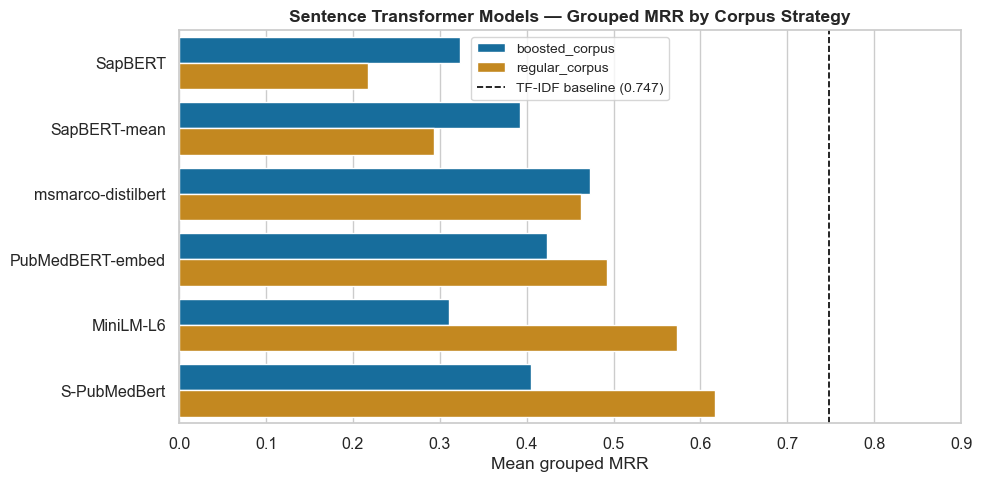

In [19]:
# Horizontal bar: model × strategy with TF-IDF baseline
st_agg = (
    df_st.groupby(['model_label', 'strategy'])['mrr_grouped'].mean()
    .unstack('strategy')
    .sort_values('regular_corpus', ascending=True)
)
st_long = st_agg.reset_index().melt(id_vars='model_label', var_name='strategy', value_name='mrr_grouped')

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=st_long, y='model_label', x='mrr_grouped', hue='strategy',
            order=st_agg.index, palette='colorblind', ax=ax,
            errorbar=None, edgecolor='white')
ax.axvline(TFIDF_BASELINE, color='black', lw=1.2, linestyle='--',
           label=f'TF-IDF baseline ({TFIDF_BASELINE:.3f})')
ax.set_xlabel('Mean grouped MRR')
ax.set_ylabel('')
ax.set_xlim(0, 0.9)
ax.set_title('Sentence Transformer Models — Grouped MRR by Corpus Strategy', fontweight='bold')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, fontsize=10)
plt.tight_layout()
plt.savefig(DATA_DIR / 'st_model_comparison.png', bbox_inches='tight')
plt.show()

Boost Δ = boosted_corpus − regular_corpus (negative = boost hurts)
strategy            boosted_corpus  regular_corpus   delta
model_label                                               
MiniLM-L6                   0.3110          0.5733 -0.2623
S-PubMedBert                0.4047          0.6170 -0.2124
PubMedBERT-embed            0.4238          0.4919 -0.0680
msmarco-distilbert          0.4730          0.4626  0.0104
SapBERT-mean                0.3918          0.2934  0.0984
SapBERT                     0.3238          0.2178  0.1059


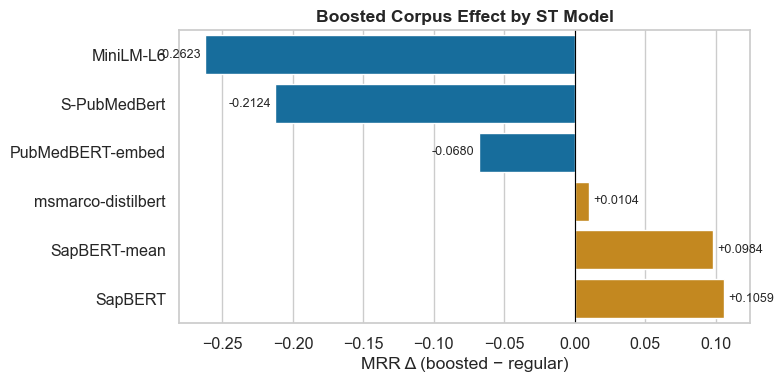

In [20]:
# Boosted corpus delta
boost_delta = (
    df_st.groupby(['model_label', 'strategy'])['mrr_grouped'].mean()
    .unstack('strategy')
    .assign(delta=lambda d: d['boosted_corpus'] - d['regular_corpus'])
    .sort_values('delta')
    .round(4)
)
print('Boost Δ = boosted_corpus − regular_corpus (negative = boost hurts)')
print(boost_delta.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
# Use hue mapped to sign so seaborn picks consistent colors
boost_long = boost_delta['delta'].reset_index()
boost_long['direction'] = boost_long['delta'].map(lambda v: 'positive' if v >= 0 else 'negative')
sns.barplot(data=boost_long, y='model_label', x='delta', hue='direction',
            order=boost_delta.index, palette='colorblind', ax=ax,
            errorbar=None, edgecolor='white', legend=False)
ax.axvline(0, color='black', lw=0.8)
for i, (_, row) in enumerate(boost_long.iterrows()):
    ax.text(row['delta'] + (0.003 if row['delta'] >= 0 else -0.003), i,
            f"{row['delta']:+.4f}", va='center',
            ha='left' if row['delta'] >= 0 else 'right', fontsize=9)
ax.set_xlabel('MRR Δ (boosted − regular)')
ax.set_ylabel('')
ax.set_title('Boosted Corpus Effect by ST Model', fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_DIR / 'st_boost_delta.png', bbox_inches='tight')
plt.show()

---
## 6. TF-IDF vs best ST comparison

C:\Users\prach\AppData\Local\Temp\ipykernel_30480\4283779853.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(present, rotation=35, ha='right', fontsize=9)


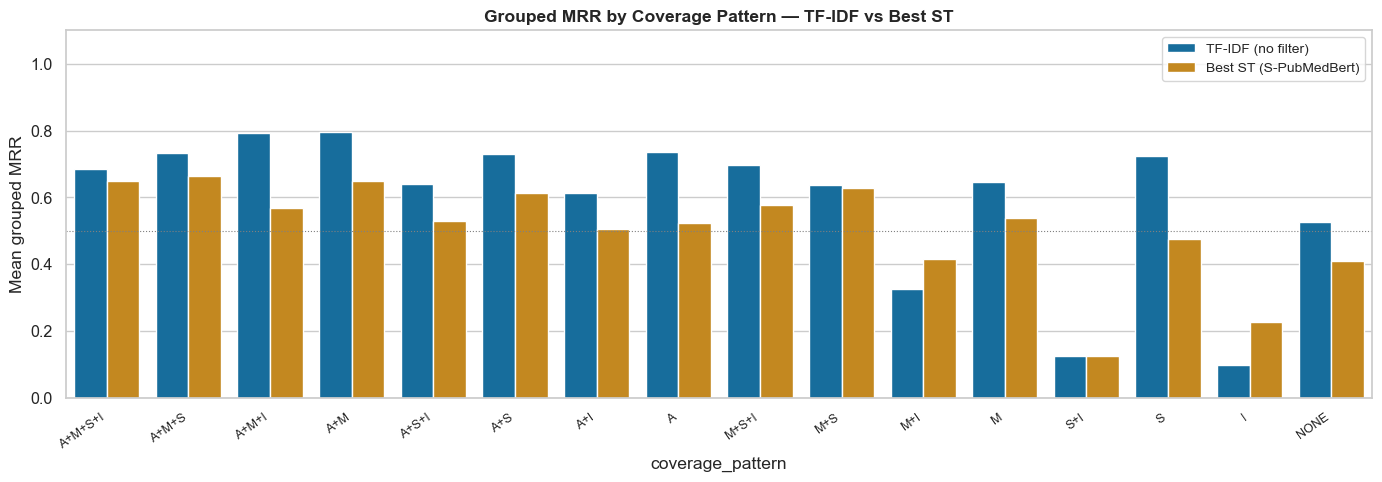


TF-IDF advantage (pp) by coverage pattern:
coverage_pattern
S          24.8300
A+M+I      22.4900
A          21.3200
A+M        14.3900
M+S+I      11.7600
NONE       11.5800
A+S        11.5300
A+S+I      10.9900
M          10.5600
A+I        10.5300
A+M+S       6.9300
A+M+S+I     3.6600
M+S         0.8900
S+I         0.0000
M+I        -8.8900
I         -12.8300


In [21]:
BEST_ST_MODEL    = 'pritamdeka/S-PubMedBert-MS-MARCO'
BEST_ST_STRATEGY = 'regular_corpus'
BEST_ST_LABEL    = MODEL_LABELS[BEST_ST_MODEL]

df_best_st = df_st[(df_st['model_type'] == BEST_ST_MODEL) & (df_st['strategy'] == BEST_ST_STRATEGY)].copy()

# Coverage pattern comparison
cov_compare = (
    pd.DataFrame({
        'TF-IDF (no filter)': df_tfidf_nf.groupby('coverage_pattern')['mrr_grouped'].mean(),
        f'Best ST ({BEST_ST_LABEL})': df_best_st.groupby('coverage_pattern')['mrr_grouped'].mean(),
    })
    .fillna(0)
)
present = [p for p in COVERAGE_ORDER if p in cov_compare.index]
cov_compare = cov_compare.reindex(present)
cov_long = cov_compare.reset_index().melt(id_vars='coverage_pattern', var_name='model', value_name='mrr_grouped')

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=cov_long, x='coverage_pattern', y='mrr_grouped', hue='model',
            order=present, palette='colorblind', ax=ax,
            errorbar=None, edgecolor='white')
ax.set_xticklabels(present, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Mean grouped MRR')
ax.set_title('Grouped MRR by Coverage Pattern — TF-IDF vs Best ST', fontweight='bold')
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color='gray', lw=0.8, linestyle=':')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(DATA_DIR / 'tfidf_vs_st_coverage.png', bbox_inches='tight')
plt.show()

print('\nTF-IDF advantage (pp) by coverage pattern:')
print(((cov_compare.iloc[:, 0] - cov_compare.iloc[:, 1]) * 100).round(2).sort_values(ascending=False).to_string())

In [22]:
cov_long.to_csv(DATA_DIR /"tfidf_vs_st_by_coverage.csv",index=False)

15:35:50 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
15:35:50 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
15:35:50 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
15:35:50 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
15:35:50 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the

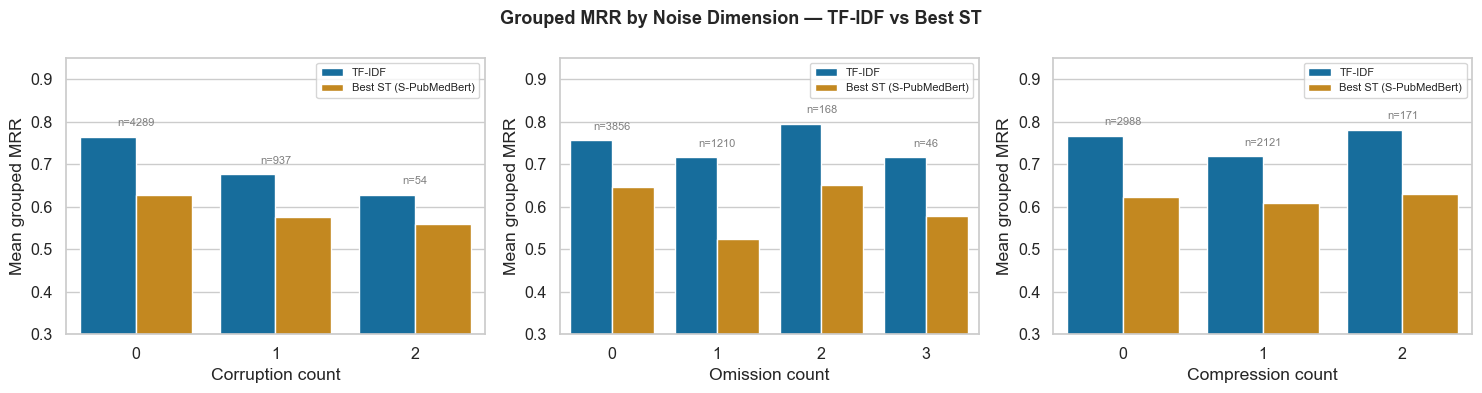

In [23]:
# Noise robustness comparison
noise_dims = [
    ('noise_corruption',       'Corruption count',       None),
    ('noise_omission',    'Omission count',    None),
    ('noise_compression', 'Compression count', None),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Grouped MRR by Noise Dimension — TF-IDF vs Best ST', fontsize=13, fontweight='bold')

for ax, (col, xlabel, order) in zip(axes, noise_dims):
    g_tfidf = df_tfidf_nf.groupby(col)['mrr_grouped'].mean()
    g_st    = df_best_st.groupby(col)['mrr_grouped'].mean()
    idx = order if order else sorted(set(g_tfidf.index) | set(g_st.index))
    idx = [v for v in idx if v in g_tfidf.index or v in g_st.index]

    noise_long = pd.DataFrame({
        'x': idx * 2,
        'mrr_grouped': list(g_tfidf.reindex(idx).fillna(0)) + list(g_st.reindex(idx).fillna(0)),
        'model': ['TF-IDF'] * len(idx) + [f'Best ST ({BEST_ST_LABEL})'] * len(idx),
    })
    sns.barplot(data=noise_long, x='x', y='mrr_grouped', hue='model',
                order=idx, palette='colorblind', ax=ax, errorbar=None, edgecolor='white')

    n_tfidf = df_tfidf_nf.groupby(col)['mrr_grouped'].count().reindex(idx).fillna(0)
    for i, (xi, n) in enumerate(zip(idx, n_tfidf)):
        top = max(g_tfidf.get(xi, 0), g_st.get(xi, 0))
        ax.text(i, top + 0.025, f'n={int(n)}', ha='center', fontsize=8, color='gray')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Mean grouped MRR')
    ax.set_ylim(0.3, 0.95)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR / 'noise_robustness.png', bbox_inches='tight')
plt.show()

In [24]:
# ST: by has_method and noise_level
for pivot_col, sort_col in [('has_method', 1), ('noise_level', 'low')]:
    print(f'Grouped MRR — ST model × {pivot_col}')
    display(
        df_st.pivot_table(values='mrr_grouped', index='model_label',
                          columns=pivot_col, aggfunc='mean')
        .sort_values(sort_col, ascending=False).round(4)
    )

Grouped MRR — ST model × has_method


has_method,0,1
model_label,,
S-PubMedBert,0.4377,0.5327
msmarco-distilbert,0.3912,0.4907
PubMedBERT-embed,0.3508,0.4898
MiniLM-L6,0.3842,0.4595
SapBERT-mean,0.3270,0.3473
SapBERT,0.2397,0.2801


Grouped MRR — ST model × noise_level


noise_level,high,low,medium
model_label,,,
S-PubMedBert,0.3888,0.5258,0.4697
msmarco-distilbert,0.3321,0.4865,0.4158
PubMedBERT-embed,0.3679,0.4683,0.4292
MiniLM-L6,0.2854,0.4569,0.4027
SapBERT-mean,0.1717,0.3434,0.3457
SapBERT,0.1970,0.2785,0.2498


---
## 7. Save summary tables

In [26]:
# Filter ablation by coverage
(
    df_filter.groupby(['filter_condition', 'coverage_pattern'])['mrr_grouped']
    .mean().unstack('filter_condition').round(4)
    .to_csv(DATA_DIR / 'filter_ablation_summary_by_coverage.csv')
)

# ST summary by model × strategy
(
    df_st.groupby(['model_label', 'strategy'])['mrr_grouped']
    .mean().unstack('strategy').round(4)
    .to_csv(DATA_DIR / 'st_summary_by_model_strategy.csv')
)

# Noise robustness summary
(
    pd.concat([
        df_tfidf_nf.groupby('noise_level')['mrr_grouped'].mean().rename('tfidf'),
        df_best_st.groupby('noise_level')['mrr_grouped'].mean().rename('best_st'),
    ], axis=1)
    .to_csv(DATA_DIR / 'noise_robustness_summary.csv')
)

# Noise robustness summary
for noise_col in ["noise_level", "noise_compression", "noise_omission", "noise_corruption"]:
    (
        pd.concat([
            df_tfidf_nf.groupby(noise_col)['mrr_grouped'].mean().rename('tfidf'),
            df_best_st.groupby(noise_col)['mrr_grouped'].mean().rename('best_st'),
        ], axis=1)
        .to_csv(DATA_DIR / f"{noise_col}_summary.csv")
    )

print('Saved summary tables to', DATA_DIR)

Saved summary tables to data\results
